In [22]:
import pandas as pd
result = pd.read_csv('251120_Highvar.csv')
result

,Filename,n_job,n_machine,Instance,I_b,I_f,RUBI Ratio,Seed,Initial Best,Best Makespan,Best Reached Time,Initialization Time,Execution Time
0,HighVar_10_10_3,10,10,3,0.388889,0.370370,RANDOM,0,1030.0,802,422.544561,1.085897,458.024736
1,HighVar_10_10_3,10,10,3,0.388889,0.370370,RUBI,0,868.0,741,263.422601,2.247828,421.558358
2,HighVar_10_10_3,10,10,3,0.388889,0.370370,MoRUBI,0,828.0,764,102.554483,2.277149,441.808032
3,HighVar_10_10_3,10,10,3,0.388889,0.370370,SPT,0,794.0,776,337.260278,2.476606,419.377311
4,HighVar_10_10_3,10,10,3,0.388889,0.370370,LPT,0,980.0,804,264.315501,2.216567,414.446552
...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,HighVar_10_10_2,10,10,2,0.400000,0.382716,RUBI,4,NaN,1013,83.732448,2.645122,516.826197
296,HighVar_10_10_2,10,10,2,0.400000,0.382716,MoRUBI,4,NaN,1008,454.943176,2.600064,489.701257
297,HighVar_10_10_2,10,10,2,0.400000,0.382716,SPT,4,NaN,1034,209.606143,2.498393,470.222518
298,HighVar_10_10_2,10,10,2,0.400000,0.382716,LPT,4,NaN,1068,9.936491,2.306576,448.120202


In [23]:
# >>> result.Filename.unique()
# array(['HighVar_10_10_0', 'HighVar_10_10_1', 'HighVar_10_10_2'], dtype=object)
# >>> result.columns
# Index(['Filename', 'n_job', 'n_machine', 'Instance', 'I_b', 'I_f',
#        'RUBI Ratio', 'Seed', 'Best Makespan', 'Best Reached Time',
#        'Initialization Time', 'Execution Time'],
#       dtype='object')

In [24]:

# 1) 필요한 열만 선택해도 되고, 그대로 groupby 해도 됨
group_cols = ['Filename', 'RUBI Ratio']   # Methodology = RUBI Ratio 열
value_col = 'Best Makespan'

# 2) Filename 과 Methodology 별 Best Makespan 평균 계산
table = (
    result
    .groupby(group_cols)[value_col]
    .mean()
    .reset_index()
    .pivot(index='Filename', columns='RUBI Ratio', values='Best Makespan')
)

# 3) 보기 좋게 정렬 (옵션)
method_order = ['RANDOM', 'RUBI', 'MoRUBI', 'SPT', 'LPT', 'GT']
table = table[method_order]


# 소수점 둘째 자리까지 반올림
table = table.round(2)

table

RUBI Ratio,RANDOM,RUBI,MoRUBI,SPT,LPT,GT
Filename,,,,,,
HighVar_10_10_0,922.8,905.6,889.6,968.8,1001.2,952.8
HighVar_10_10_1,864.6,848.4,836.6,822.2,872.0,850.2
HighVar_10_10_2,962.2,992.4,1003.4,1009.4,1036.6,935.2
HighVar_10_10_3,829.6,765.4,767.0,764.2,813.0,813.6
HighVar_10_10_4,908.4,895.6,908.0,915.2,933.4,921.0
HighVar_10_10_5,803.2,773.8,780.4,772.6,796.6,797.0
HighVar_10_10_6,853.8,864.4,861.4,826.6,851.2,840.6
HighVar_10_10_7,1025.0,1043.8,1048.0,1048.4,1070.0,1012.2
HighVar_10_10_8,912.8,901.6,901.8,916.2,962.8,931.8


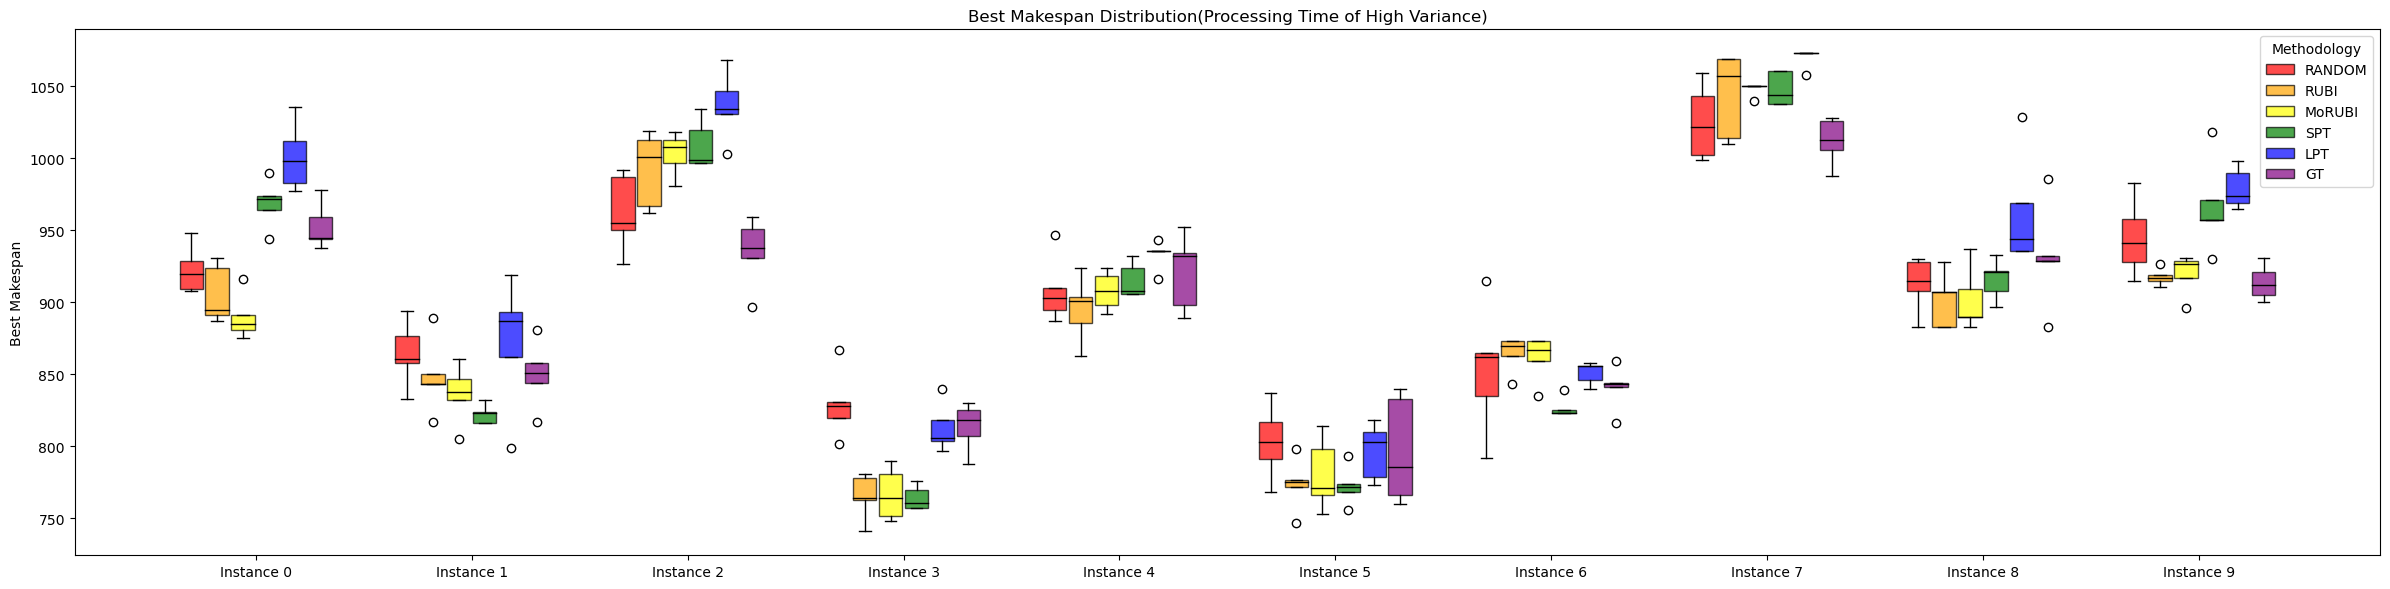

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# 방법론 순서 및 색 정의
methods = ['RANDOM', 'RUBI', 'MoRUBI', 'SPT', 'LPT', 'GT']
colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple']

# x축에 올 Filename 순서
filenames = sorted(result['Filename'].unique())
x = np.arange(len(filenames))

# 박스들을 옆으로 살짝씩 밀기 위한 간격
width = 0.12  # 박스 중심 간격

fig, ax = plt.subplots(figsize=(24, 6))

legend_handles = []
legend_labels = []

for i, (m, c) in enumerate(zip(methods, colors)):
    # 각 Filename 에 대해, 해당 Methodology(m) 의 Best Makespan 리스트를 모음
    data = [
        result.loc[
            (result['Filename'] == fn) & (result['RUBI Ratio'] == m),
            'Best Makespan'
        ].values
        for fn in filenames
    ]
    
    # 이 방법론의 박스플롯을 약간 이동된 위치에 그림
    positions = x + (i - (len(methods) - 1) / 2) * width
    
    bp = ax.boxplot(
        data,
        positions=positions,
        widths=width * 0.9,
        patch_artist=True,
        manage_ticks=False
    )
    
    # 박스 색, 투명도, 중앙선 스타일 지정
    for patch in bp['boxes']:
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(1.0)
    
    # legend용 핸들 하나만 저장
    legend_handles.append(bp['boxes'][0])
    legend_labels.append(m)

# 축/레이블 설정
ax.set_xticks(x)
ax.set_xticklabels([f'Instance {i}' for i in range(len(filenames))], ha='center')
# ax.set_xlabel('Filename')
ax.set_ylabel('Best Makespan')
ax.set_title('Best Makespan Distribution(Processing Time of High Variance)')

ax.legend(legend_handles, legend_labels, title='Methodology', loc='best')

fig.tight_layout()
# plt.show()
plt.savefig('HighVar_0_2.png', dpi=300)
